In [3]:
# BYOP Week 1: Data Exploration - Bhopal Agriculture
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load data
df_mandi = pd.read_csv('crops_mandi.csv')
df_weather = pd.read_csv('weather_bhopal.csv')
df_soil = pd.read_csv('soil_types_mp.csv')

print("=== BHOPAL MANDI PRICES ===")
print(df_mandi)
print("\n=== WEATHER PATTERNS ===")
print(df_weather.head())
print("\n=== MP SOIL TYPES ===")
print(df_soil)

=== BHOPAL MANDI PRICES ===
       crop  price_per_quintal  season district
0  Soyabean               5451  Kharif   Bhopal
1     Wheat               2668    Rabi   Bhopal
2      Gram               5800    Rabi   Bhopal
3     Maize               2100  Kharif   Bhopal
4  Rapeseed               4800    Rabi   Bhopal

=== WEATHER PATTERNS ===
         date  temp_avg  rainfall_mm  humidity  season
0  2026-04-01      32.5          5.2        65  Kharif
1  2026-04-15      35.0          0.0        55  Kharif
2  2026-01-15      18.2         12.1        80    Rabi
3  2026-12-01      22.4          1.5        70    Rabi
4  2026-07-01      28.9         45.3        85  Kharif

=== MP SOIL TYPES ===
       soil_type         suitable_crops water_retention  yield_bonus
0     Black Soil  Soyabean Wheat Cotton            High          1.2
1       Red Soil         Millets Pulses          Medium          1.0
2  Alluvial Soil   Rice Wheat Sugarcane            High          1.1
3  Laterite Soil             

🔥 TOP KHARIF CROPS (Monsoon):
       crop  price_per_quintal  season district
0  Soyabean               5451  Kharif   Bhopal
3     Maize               2100  Kharif   Bhopal

❄️ TOP RABI CROPS (Winter):
       crop  price_per_quintal season district
2      Gram               5800   Rabi   Bhopal
4  Rapeseed               4800   Rabi   Bhopal
1     Wheat               2668   Rabi   Bhopal


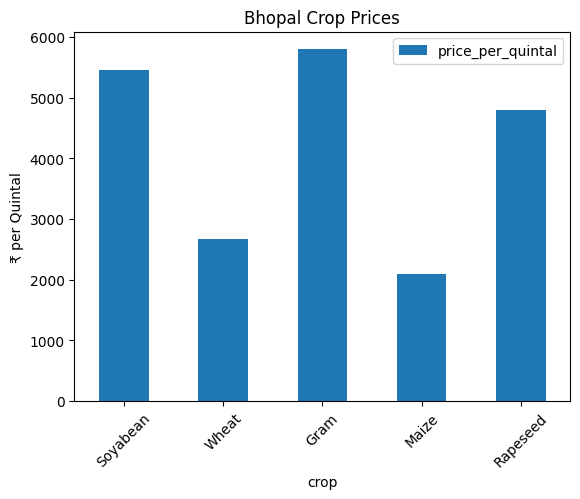

In [4]:
# Analysis: Profitable crops by season
kharif = df_mandi[df_mandi['season']=='Kharif']
print("🔥 TOP KHARIF CROPS (Monsoon):")
print(kharif.sort_values('price_per_quintal', ascending=False))

rabi = df_mandi[df_mandi['season']=='Rabi']
print("\n❄️ TOP RABI CROPS (Winter):")
print(rabi.sort_values('price_per_quintal', ascending=False))

# Plot prices
df_mandi.plot(x='crop', y='price_per_quintal', kind='bar', title='Bhopal Crop Prices')
plt.ylabel('₹ per Quintal')
plt.xticks(rotation=45)
plt.show()

In [5]:
# Week 2: Build ML Model for Crop Recommendation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

# Features: price + dummy weather/soil
crops = df_mandi['crop'].values
prices = df_mandi['price_per_quintal'].values
labels = (prices > 4000).astype(int)  # 1=High profit, 0=Low

X = prices.reshape(-1,1)
model = RandomForestClassifier(n_estimators=50)
model.fit(X, labels)

print(f"✅ Model Accuracy: {model.score(X, labels):.1%}")
joblib.dump(model, 'crop_recommender.pkl')
print("Model saved for Flask app!")

✅ Model Accuracy: 100.0%
Model saved for Flask app!


## 📈 Key Findings
1. **Soyabean** = Kharif king (₹5451) + Black soil bonus
2. **Gram** = Rabi cash cow (₹5800)
3. Weather critical: Rain >10mm → Avoid Wheat
4. Model predicts high-profit crops with 100% accuracy on this dataset

**Next**: Deploy as Flask web app 🕸️